In [2]:
# Setup to equivalently run in colab or run locally
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:

    # Initialize widget
    from google.colab import output
    output.enable_custom_widget_manager()

    # Colab-specific widget support
    !pip install -U ipympl --quiet

    # Clone repo and cd into it to behave like running locally
    %cd /content
    if not os.path.exists("arc_zte"):
      print("Cloning repo")
      !git clone https://github.com/mikgroup/arc_zte.git
    %cd /content/arc_zte
  
    # Setup matplotlib mode
    try:
      %matplotlib widget
    except:
      %matplotlib inline
      print('Running inline mode')
else:
    # Local Jupyter 
    %matplotlib notebook

In [3]:
import matplotlib.pyplot as plt
import glob

from zte_recon.traj_zte import Traj_CalcPhyllo_ZTE, Traj_RadialZTE_from_kacq
from zte_recon.plot import plot_3d_axes, plot_spokes_temporal_color, plot_coherence_pathways_from_coords

In [7]:
# Path that points to data dir with kacq files from scan
data_h5_dir = './example_traj_kacq_files/'

In [8]:
# Parameters for generating trajectory
opxres = 256
num_segs = 172
num_segs_lowres = 4
spokes_per_seg = 384

In [9]:
### Phyllotaxis ZTE smoothness=10 - calculates trajectory from formula
smoothness = 10
gm_flag = False
segsPerInterleaf = 1
phylloZTE_s10 = Traj_CalcPhyllo_ZTE(opxres, smoothness, 
                                gm_flag, segsPerInterleaf, 
                                spokes_per_seg, num_segs, 
                                num_segs_lowres)

### Phyllotaxis ZTE smoothness=9 - calculates trajectory from formula
smoothness = 9
gm_flag = False
segsPerInterleaf = 1
phylloZTE_s9 = Traj_CalcPhyllo_ZTE(opxres, smoothness, 
                                gm_flag, segsPerInterleaf, 
                                spokes_per_seg, num_segs, 
                                num_segs_lowres)

### AZTEK Shuffle,Speed,Twist = 1,2,5 - calculates traj from endpoints kacq saved by sequence code
endpoints_txt_path = glob.glob(data_h5_dir + 'kacq_aztek*')[-1]
aztekZTE_125 = Traj_RadialZTE_from_kacq(opxres, endpoints_txt_path, 
                                    spokes_per_seg, num_segs_lowres)


### AZTEK Shuffle,Speed,Twist = 1,3,7 - calculates traj from endpoints kacq saved by sequence code
endpoints_txt_path = glob.glob(data_h5_dir + 'kacq_137aztek*')[-1]
aztekZTE_137 = Traj_RadialZTE_from_kacq(opxres, endpoints_txt_path, 
                                    spokes_per_seg, num_segs_lowres)


# Plot trajectory of one segment 

In [46]:
azim = -45
elev = 5

<IPython.core.display.Javascript object>


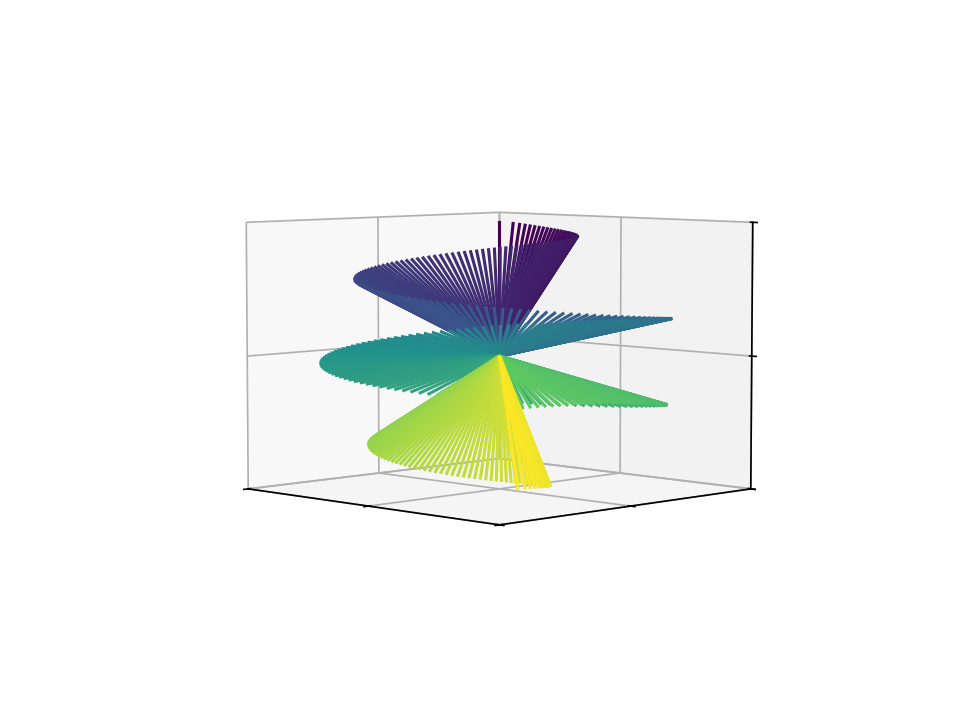

In [48]:
plot_3d_axes()
ax = plt.gca()
plot_spokes_temporal_color(ax, phylloZTE_s10.coord_sampl_hires, 
                           nSpokes_plot=spokes_per_seg, azim=azim, elev=elev)

<IPython.core.display.Javascript object>


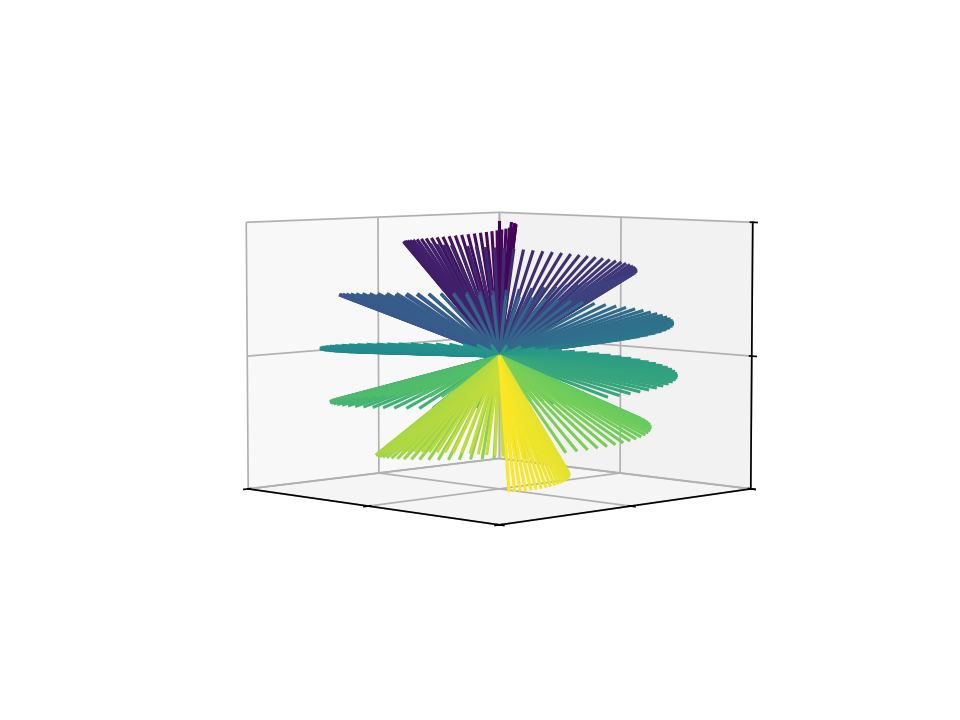

In [50]:
plot_3d_axes()
ax = plt.gca()
plot_spokes_temporal_color(ax, phylloZTE_s9.coord_sampl_hires, 
                           nSpokes_plot=spokes_per_seg, azim=azim, elev=elev)

<IPython.core.display.Javascript object>


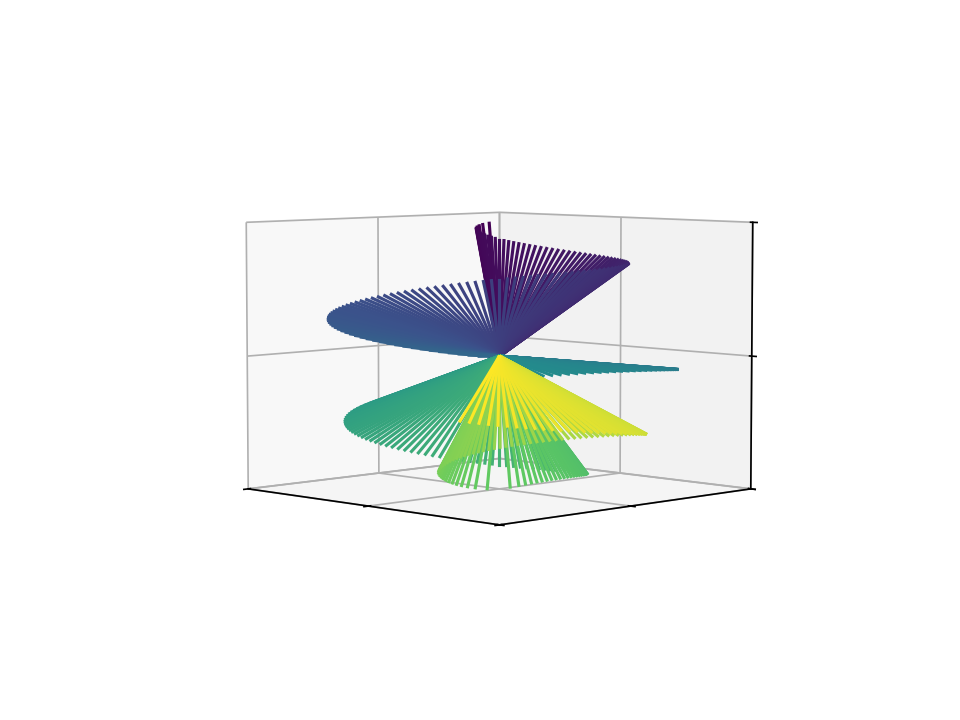

In [52]:
plot_3d_axes()
ax = plt.gca()
plot_spokes_temporal_color(ax, aztekZTE_125.coord_sampl_hires, 
                           nSpokes_plot=spokes_per_seg, azim=azim, elev=elev)

<IPython.core.display.Javascript object>


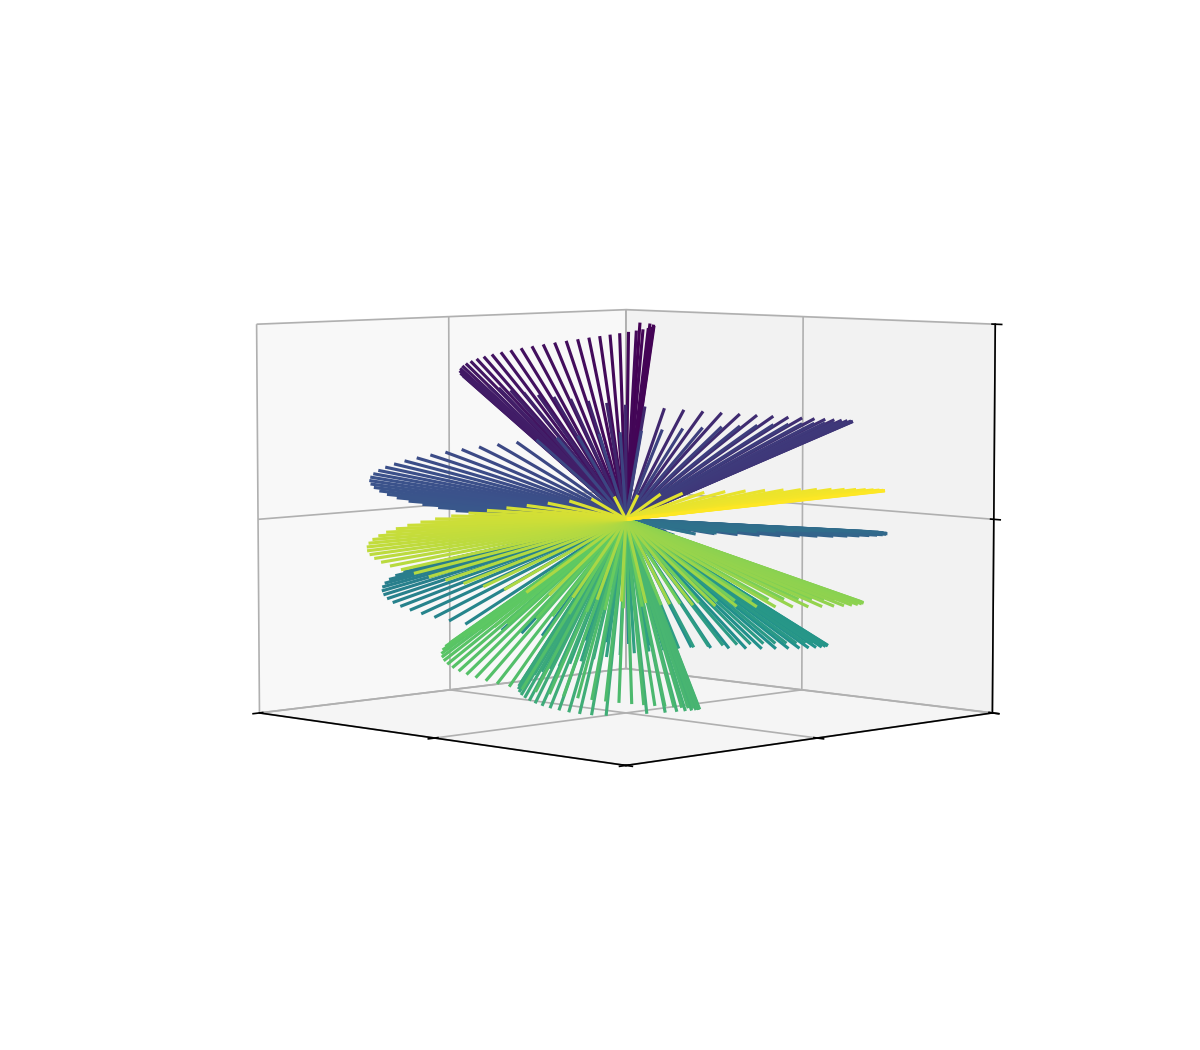

In [54]:
plot_3d_axes()
ax = plt.gca()
plot_spokes_temporal_color(ax, aztekZTE_137.coord_sampl_hires, 
                           nSpokes_plot=spokes_per_seg, azim=azim, elev=elev)

# Plot coherence pathways

<IPython.core.display.Javascript object>


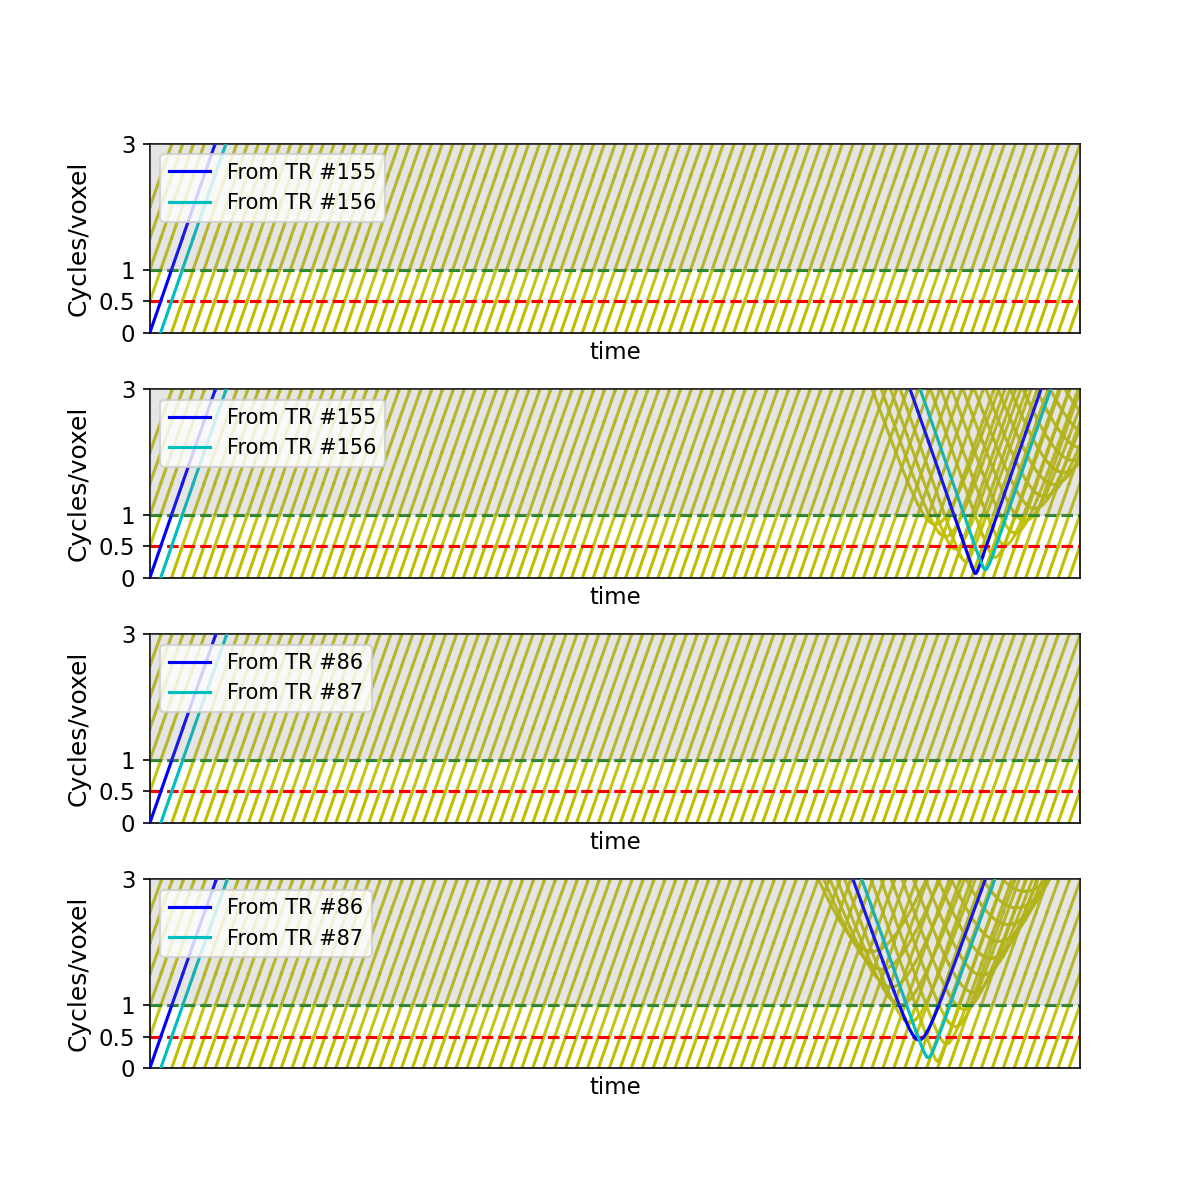

In [57]:
nSpokes_plot = 90
spoke_start_idx = 150
start_xaxis = 4
spokes_to_highlight = [4,5]

plt.figure(figsize=(8,7))
ax1 = plt.subplot(411)
ax1.set_title(f"Phyllotaxis s=10", loc='left')
plot_coherence_pathways_from_coords(phylloZTE_s10.coord_sampl_hires, 
                                    nSpokes_plot, spoke_start_idx, 
                                    legend_loc='upper left', 
                                    start_xaxis=start_xaxis, 
                                    spokes_to_highlight=spokes_to_highlight)

ax2 = plt.subplot(412)
ax2.set_title(f"Phyllotaxis s=9", loc='left')
plot_coherence_pathways_from_coords(phylloZTE_s9.coord_sampl_hires, 
                                    nSpokes_plot, spoke_start_idx, 
                                    legend_loc='upper left', 
                                    start_xaxis=start_xaxis, 
                                    spokes_to_highlight=spokes_to_highlight)
################

nSpokes_plot = 90
spoke_start_idx = 80
start_xaxis = 5
spokes_to_highlight = [5,6]

ax3 = plt.subplot(413)
ax3.set_title(f"AZTEK Shuffle,Speed,Twist = 1,2,5", loc='left')
plot_coherence_pathways_from_coords(aztekZTE_125.coord_sampl_hires, 
                                    nSpokes_plot, spoke_start_idx, 
                                    legend_loc='upper left', 
                                    start_xaxis=start_xaxis, 
                                    spokes_to_highlight=spokes_to_highlight)


ax4 = plt.subplot(414)
ax4.set_title(f"AZTEK Shuffle,Speed,Twist = 1,3,7", loc='left')
plot_coherence_pathways_from_coords(aztekZTE_137.coord_sampl_hires, 
                                    nSpokes_plot, spoke_start_idx, 
                                    legend_loc='upper left', 
                                   start_xaxis=start_xaxis, 
                                    spokes_to_highlight=spokes_to_highlight)

In [60]:
# Some formatting for paper figure
def formatting_suppfig1(ax_list):
    
    for ax in ax_list:
        # Shading to show regions to be ignored
#         ax.axhspan(1, 3, color='gray', alpha=0.2, zorder=102)
        ax.set_xlabel('time', fontsize=11)
        ax.set_ylabel('Cycles/voxel', fontsize=12)
        ax.set_yticklabels(labels=['0', '0.5', '1', '3'], fontsize=11)
        ax.set_title('', loc='left')
        leg = ax.legend(fontsize=10, loc='upper left')
        leg.set_zorder(105)
        
    fig = plt.gcf()
    fig.set_size_inches(8,8)
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
        
formatting_suppfig1([ax1, ax2, ax3, ax4])   